zaczytanie niezbędnych bibliotek

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

zaczytaj dane dotyczace sprzedazy

In [50]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "/content/Salary Data (2) (1).csv"

# Load the latest version
df = pd.read_csv(file_path)
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas

print("First 5 records:", df.head())

First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


preprocessing

1.   sprawdż typy danych
2.   zmien etykiedy na zmienne liczbowe
3. w przypadku brakujacych danych uzupelnij (w przypadku etykiet) najczesciej wystepującą wartością lub średnią wartością



In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [52]:
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])

df['Education Level'] = label_encoder.fit_transform(df['Education Level'])

df['Job Title'] = label_encoder.fit_transform(df['Job Title'])


In [53]:
for column in df.columns:
  df[column].fillna(df[column].mean(), inplace=True)

<ipython-input-53-69eacf26a006>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


Podziel zbiór danych na testowy i treningowy w stosunku 30/70

In [25]:

X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Stworz model regresji liniowej korzystajac z parametrów domyślnych
Przykład dokumentacji: https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols.html#sphx-glr-auto-examples-linear-model-plot-ols-py

In [26]:
regressor = LinearRegression().fit(X_train, y_train)

ocen model na zbiorze testowym za pomocą miar: średni błąd kwadratowy, średni błąd absolutny, wynik wyjaśnionej wariancji

In [27]:
# prompt: ocen model na zbiorze testowym za pomocą miar: średni błąd kwadratowy, średni błąd absolutny, wynik wyjaśnionej wariancji

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

print("Średni błąd kwadratowy (MSE):", mse)
print("Średni błąd absolutny (MAE):", mae)
print("Wynik wyjaśnionej wariancji (EVS):", evs)


Średni błąd kwadratowy (MSE): 251384617.98392048
Średni błąd absolutny (MAE): 10976.816634914625
Wynik wyjaśnionej wariancji (EVS): 0.8830175673765588


spróbuj poprawić model, zacznij od danych, sprawdz korelacje, znormalizuj

Correlation Matrix:
                           Age    Gender  Education Level  Job Title  \
Age                  1.000000 -0.019865         0.546020   0.116616   
Gender              -0.019865  1.000000         0.008677   0.041562   
Education Level      0.546020  0.008677         1.000000   0.127791   
Job Title            0.116616  0.041562         0.127791   1.000000   
Years of Experience  0.979128  0.002818         0.573355   0.099299   
Salary               0.922335  0.069498         0.650507   0.135033   

                     Years of Experience    Salary  
Age                             0.979128  0.922335  
Gender                          0.002818  0.069498  
Education Level                 0.573355  0.650507  
Job Title                       0.099299  0.135033  
Years of Experience             1.000000  0.930338  
Salary                          0.930338  1.000000  


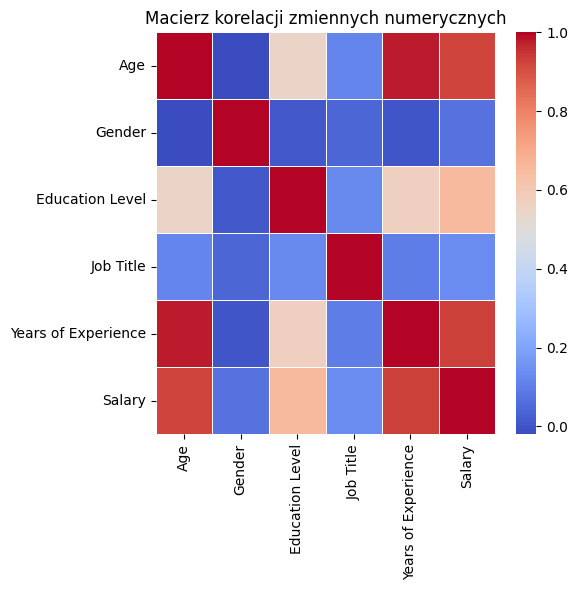

In [33]:
import seaborn as sns
# Check correlation
correlation_matrix = df.corr()
print("Correlation Matrix:\n", correlation_matrix)

# Wizualizacja jako heatmapa
plt.figure(figsize=(6, 6))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Macierz korelacji zmiennych numerycznych')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
# Try different models like Ridge or Lasso Regression
# ridge_regressor = Ridge().fit(X_train, y_train)
# lasso_regressor = Lasso().fit(X_train, y_train)

# Evaluate these models as well and compare the results

# You can also try feature engineering,
# removing less relevant features, or using more advanced models to improve performance.


In [40]:
if 'Age' in X.columns:
  X = X.drop('Age', axis=1)

Correlation Matrix:
                        Gender  Education Level  Job Title  Years of Experience
Gender               1.000000         0.008677   0.041562             0.002818
Education Level      0.008677         1.000000   0.127791             0.573355
Job Title            0.041562         0.127791   1.000000             0.099299
Years of Experience  0.002818         0.573355   0.099299             1.000000


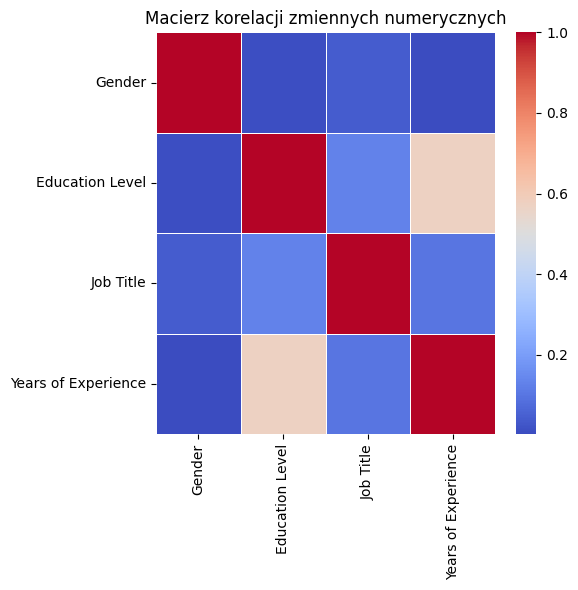

Średni błąd kwadratowy (MSE): 251384617.9839179
Średni błąd absolutny (MAE): 10976.81663491446
Wynik wyjaśnionej wariancji (EVS): 0.8830175673765599


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

regressor = LinearRegression().fit(X_train, y_train)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

correlation_matrix = X.corr()
print("Correlation Matrix:\n", correlation_matrix)

# Wizualizacja jako heatmapa
plt.figure(figsize=(6, 6))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Macierz korelacji zmiennych numerycznych')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Średni błąd kwadratowy (MSE):", mse)
print("Średni błąd absolutny (MAE):", mae)
print("Wynik wyjaśnionej wariancji (EVS):", evs)

Zbuduj model regresji odpornej i przetestuj jego predykcje

In [46]:
# prompt: Zbuduj model regresji odpornej i przetestuj jego predykcje

from sklearn.linear_model import HuberRegressor

# Tworzenie modelu regresji odpornej (HuberRegressor)
huber_regressor = HuberRegressor().fit(X_train, y_train)

# Predykcja na zbiorze testowym
y_pred_huber = huber_regressor.predict(X_test)

# Ocena modelu
mse_huber = mean_squared_error(y_test, y_pred_huber)
mae_huber = mean_absolute_error(y_test, y_pred_huber)
evs_huber = explained_variance_score(y_test, y_pred_huber)

print("Huber Regressor:")
print("Średni błąd kwadratowy (MSE):", mse_huber)
print("Średni błąd absolutny (MAE):", mae_huber)
print("Wynik wyjaśnionej wariancji (EVS):", evs_huber)


Huber Regressor:
Średni błąd kwadratowy (MSE): 239179818.8927343
Średni błąd absolutny (MAE): 10934.537221118748
Wynik wyjaśnionej wariancji (EVS): 0.8878534876950125


Wykreś przewidziane i faktyczne wartości obu modeli (przykład w dokumentacji: https://scikit-learn.org/stable/auto_examples/ensemble/plot_voting_regressor.html#sphx-glr-auto-examples-ensemble-plot-voting-regressor-py)

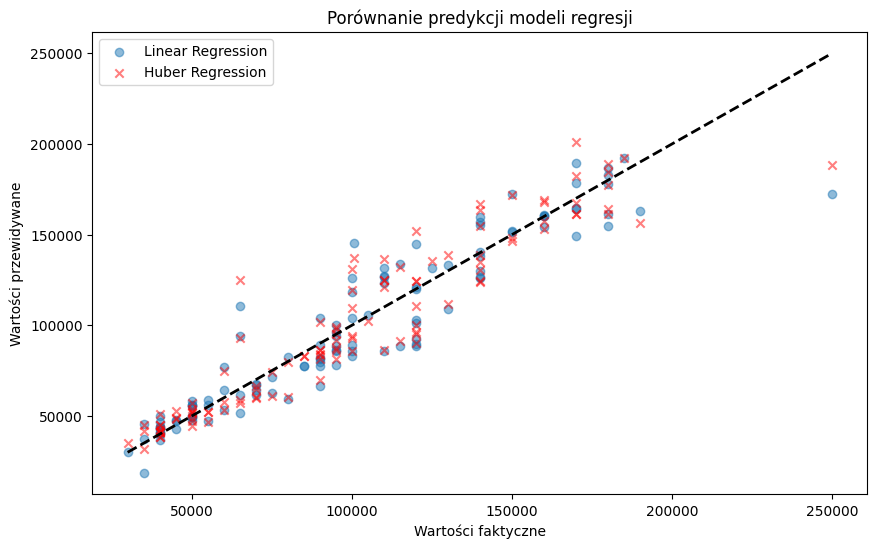

In [48]:
# prompt: Wykreś przewidziane i faktyczne wartości obu modeli

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, label='Linear Regression', alpha=0.5)
plt.scatter(y_test, y_pred_huber, label='Huber Regression', alpha=0.5, marker='x', color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Wartości faktyczne')
plt.ylabel('Wartości przewidywane')
plt.title('Porównanie predykcji modeli regresji')
plt.legend()
plt.show()


Zmodyfikuj kod, zeby zwizualizować wynik lepszego z modeli